In [2]:
%load_ext lab_black
%load_ext autoreload
%autoreload 2
%matplotlib inline


In [19]:
import os
import pickle
import numpy as np
from mne_connectivity.viz import plot_connectivity_circle
from mne.viz import circular_layout
import matplotlib.pyplot as plt
import numpy as np
import pickle


def create_hierarchy():
    hierarchy = {}
    fmin_fmax = [(1, 4), (4, 8), (8, 12), (13, 30), (30, 50), (1, 120)]
    conditions = range(1, 7)
    patients = range(2, 22)
    states = ["pre", "during", "post"]

    for fmin, fmax in fmin_fmax:
        filter_key = f"{fmin}_{fmax}"
        hierarchy[filter_key] = {}
        for condition in conditions:
            hierarchy[filter_key][condition] = {}
            for patient in patients:
                hierarchy[filter_key][condition][patient] = {}
                folder = f"D:\\neuro-closeloop-project\\vielight_close_loop\\notebooks\\csd\\filters\\{filter_key}\\conditions\\{condition}\\results\\{patient}"
                if os.path.exists(folder) and os.listdir(folder):
                    for state in states:
                        pickle_file = os.path.join(
                            folder, f"{patient}_{state}_connectivity.pkl"
                        )
                        if os.path.exists(pickle_file):
                            with open(pickle_file, "rb") as f:
                                hierarchy[filter_key][condition][patient][state] = (
                                    pickle.load(f)
                                )
                        else:
                            print(f"Missing pickle file: {pickle_file}")
                            hierarchy[filter_key][condition][patient][state] = None
                else:
                    print(f"Empty or non-existent folder: {folder}")
                    for state in states:
                        hierarchy[filter_key][condition][patient][state] = None

    return hierarchy


In [20]:
# Usage
hierarchy = create_hierarchy()
print(hierarchy.keys())
print(hierarchy["1_120"].keys())
print(hierarchy["1_120"][1].keys())
print(hierarchy["1_120"][1][2].keys())
print(hierarchy["1_120"][1][2]["pre"])


Empty or non-existent folder: D:\neuro-closeloop-project\vielight_close_loop\notebooks\csd\filters\1_4\conditions\1\results\16
Empty or non-existent folder: D:\neuro-closeloop-project\vielight_close_loop\notebooks\csd\filters\1_4\conditions\2\results\16
Empty or non-existent folder: D:\neuro-closeloop-project\vielight_close_loop\notebooks\csd\filters\1_4\conditions\3\results\16
Empty or non-existent folder: D:\neuro-closeloop-project\vielight_close_loop\notebooks\csd\filters\1_4\conditions\4\results\16
Empty or non-existent folder: D:\neuro-closeloop-project\vielight_close_loop\notebooks\csd\filters\1_4\conditions\5\results\13
Empty or non-existent folder: D:\neuro-closeloop-project\vielight_close_loop\notebooks\csd\filters\1_4\conditions\6\results\2
Empty or non-existent folder: D:\neuro-closeloop-project\vielight_close_loop\notebooks\csd\filters\1_4\conditions\6\results\6
Empty or non-existent folder: D:\neuro-closeloop-project\vielight_close_loop\notebooks\csd\filters\1_4\conditions

# Visualization

In [21]:
def get_channel_5_colors():
    return [
        "AF3",
        "F1",
        "F3",
        "F5",
        "F7",
        "FC1",
        "FC3",
        "FC5",
        "FCZ",
        "FP1",
        "FPZ",
        "FT7",
        "FZ",
        "C1",
        "C3",
        "C5",
        "CZ",
        "T7",
        "TP7",
        "CP1",
        "CP3",
        "CP5",
        "P1",
        "P3",
        "P5",
        "P7",
        "PO3",
        "PO5",
        "PO7",
        "O1",
        "POZ",
        "OZ",
        "PZ",
        "CPZ",
        "TP8",
        "T8",
        "PO8",
        "PO6",
        "PO4",
        "O2",
        "P8",
        "P6",
        "P4",
        "P2",
        "CP6",
        "CP4",
        "CP2",
        "C6",
        "C4",
        "C2",
        "FT8",
        "FP2",
        "FC6",
        "FC4",
        "FC2",
        "F8",
        "F6",
        "F4",
        "F2",
        "AF4",
    ]


def assign_channel_5_colors():
    red = (0.458, 0.0, 0.0, 1.0)
    green = (0.0, 1.0, 0.0, 1.0)
    blue = (0.0, 0.0, 0.999, 1.0)
    purple = (0.5, 0.0, 0.5, 1.0)
    orange = (1.0, 0.647, 0.0, 1.0)
    black = (0.0, 0.0, 0.0, 1.0)

    # New color for separators
    channel_color = {
        # Frontal (Red)
        "AF3": red,
        "AF4": red,
        "F1": red,
        "F2": red,
        "F3": red,
        "F4": red,
        "F5": red,
        "F6": red,
        "F7": red,
        "F8": red,
        "FC1": red,
        "FC2": red,
        "FC3": red,
        "FC4": red,
        "FC5": red,
        "FC6": red,
        "FCZ": red,
        "FP1": red,
        "FP2": red,
        "FPZ": red,
        "FT7": red,
        "FT8": red,
        "FZ": red,
        # Central (Green)
        "C1": green,
        "C2": green,
        "C3": green,
        "C4": green,
        "C5": green,
        "C6": green,
        "CZ": green,
        # Parietal (Blue)
        "CP1": blue,
        "CP2": blue,
        "CP3": blue,
        "CP4": blue,
        "CP5": blue,
        "CP6": blue,
        "CPZ": blue,
        "P1": blue,
        "P2": blue,
        "P3": blue,
        "P4": blue,
        "P5": blue,
        "P6": blue,
        "P7": blue,
        "P8": blue,
        "PZ": blue,
        # Occipital (Purple)
        "O1": purple,
        "O2": purple,
        "OZ": purple,
        "PO3": purple,
        "PO4": purple,
        "PO5": purple,
        "PO6": purple,
        "PO7": purple,
        "PO8": purple,
        "POZ": purple,
        # Temporal (Orange)
        "T7": orange,
        "T8": orange,
        "TP7": orange,
        "TP8": orange,
    }

    return channel_color


def prepare_circular_layout(label_names):
    """
    Prepare the circular layout for the connectivity plot.

    Args:
    label_names (list): List of channel names.

    Returns:
    tuple: Node angles and node order for the circular layout.
    """
    n_channels = len(label_names)
    node_angles = circular_layout(
        label_names,
        label_names,
        start_pos=90,
        group_boundaries=[0, len(label_names) // 2],
    )
    node_order = label_names
    return node_angles, node_order


def get_circular_plot_requirements(label_names):
    """
    Get the requirements for a circular connectivity plot with left channels first.

    Args:
    label_names (list): List of channel names.

    Returns:
    tuple: Node angles, node order, and node colors for the circular plot.
    """

    sorted_channels = get_channel_5_colors()

    # Assign colors to channels
    # channel_color = assign_channel_colors(channels_side, left_color, right_color)
    channel_color = assign_channel_5_colors()

    # Prepare circular layout with sorted channels
    node_angles, _ = prepare_circular_layout(list(channel_color.keys()))

    # Get node colors in the same order as sorted_channels
    node_colors = [channel_color[channel] for channel in sorted_channels]

    return node_angles, sorted_channels, node_colors


def plot_circular_connectivity(
    connectivity,
    stage,
    label_names,
    node_angles,
    node_colors,
    method="wpli",
    is_save=False,
    n_lines=20,
    figsize=(8, 8),
):
    """
    Plot circular connectivity diagram.

    Args:
    connectivity (mne.Connectivity): The connectivity object.
    stage (str): The stage of the experiment (e.g., 'pre', 'during', 'post').
    label_names (list): List of channel names.
    node_angles (dict): Dictionary of node angles for the circular plot.
    node_colors (list): List of colors for each node.
    method (str, optional): Connectivity method used. Defaults to "wpli".
    is_save (bool, optional): Whether to save the figure. Defaults to False.
    n_lines (int, optional): Number of connections to draw. Defaults to 20.
    figsize (tuple, optional): Figure size. Defaults to (8, 8).

    Returns:
    matplotlib.figure.Figure: The created figure.
    """
    # Create figure
    fig, ax = plt.subplots(
        figsize=figsize, facecolor="black", subplot_kw=dict(polar=True)
    )

    if not isinstance(connectivity, np.ndarray):
        connectivity = connectivity.get_data("dense")[:, :, 0]

    if connectivity.ndim == 3:
        connectivity = connectivity[:, :, 0]

    print(f"{len(node_angles) = }")
    print(f"{len(node_colors) = }")

    # Plot connectivity circle
    plot_connectivity_circle(
        con=connectivity,
        node_names=label_names,
        n_lines=n_lines,
        node_angles=node_angles,
        node_colors=node_colors,
        title=f"All-to-All Connectivity {stage} stimuli Condition ({method})",
        ax=ax,
    )

    # Adjust layout
    fig.tight_layout()

    # Save figure if requested
    if is_save:
        filename = f"{method}_{stage}.png"
        fig.savefig(filename, dpi=300)
        print(f"Figure saved as {filename}")

    return fig


def prepare_plot_data(hierarchy, freq_band, condition, patient, state):
    """
    Extract data from the hierarchy and prepare for plotting.

    Args:
    hierarchy (dict): The hierarchical data structure
    freq_band (str): Frequency band key (e.g., '1_4', '4_8', etc.)
    condition (int): Condition number (1-6)
    patient (int): Patient number (2-21)
    state (str): State ('pre', 'during', 'post')

    Returns:
    tuple: connectivity_data, node_angles, node_order, node_colors
    """
    # Extract SpectralConnectivity object
    spectral_conn = hierarchy[freq_band][condition][patient][state]

    if spectral_conn is None:
        raise ValueError(
            f"No data for {freq_band}, condition {condition}, patient {patient}, state {state}"
        )

    # Extract connectivity data
    connectivity_data = spectral_conn.get_data(output="dense")[
        :, :, 0
    ]  # Assuming first frequency

    # Get channel names
    channel_names = get_channel_5_colors()

    # Prepare circular layout
    node_angles, node_order, node_colors = get_circular_plot_requirements(channel_names)

    return connectivity_data, node_angles, node_order, node_colors


In [ ]:
def plot_residual_connectivity(
    hierarchy,
    freq_band,
    condition,
    patient,
    state1="pre",
    state2="post",
    n_lines=20,
    figsize=(8, 8),
    is_save=False,
):
    """
    Plot residual connectivity between two states (state2 - state1) in a single plot.
    Shows both top positive and top negative connections simultaneously.

    Args:
        hierarchy (dict): The hierarchical data structure
        freq_band (str): Frequency band key (e.g., '1_4', '4_8', etc.)
        condition (int): Condition number (1-6)
        patient (int): Patient number (2-21)
        state1 (str): First state ('pre', 'during', 'post'). Default is 'pre'
        state2 (str): Second state ('pre', 'during', 'post'). Default is 'post'
        n_lines (int): Number of strongest connections to show (will show n_lines/2 for each of positive and negative)
        figsize (tuple): Figure size. Default is (8, 8)
        is_save (bool): Whether to save the figure. Default is False

    Returns:
        matplotlib.figure.Figure: The created figure
    """
    # Get data for both states
    conn1 = hierarchy[freq_band][condition][patient][state1]
    conn2 = hierarchy[freq_band][condition][patient][state2]

    if conn1 is None or conn2 is None:
        raise ValueError(f"No data for specified parameters in {state1} or {state2}")

    # Convert to dense arrays and get first frequency
    conn1_data = conn1.get_data(output="dense")[:, :, 0]
    conn2_data = conn2.get_data(output="dense")[:, :, 0]

    # Calculate residual (state2 - state1)
    residual = conn2_data - conn1_data

    # Create a mask for top positive and negative connections
    n_lines_each = n_lines // 2  # Split n_lines between positive and negative

    # Get the indices of top positive and negative connections
    pos_flat_idx = np.argsort(residual.flatten())[-n_lines_each:]
    neg_flat_idx = np.argsort(residual.flatten())[:n_lines_each]

    # Create a mask for selected connections
    mask = np.zeros_like(residual, dtype=bool)
    mask.flat[pos_flat_idx] = True
    mask.flat[neg_flat_idx] = True

    # Create masked residual matrix
    masked_residual = np.zeros_like(residual)
    masked_residual[mask] = residual[mask]

    # Get channel information
    channel_names = get_channel_5_colors()
    node_angles, node_order, node_colors = get_circular_plot_requirements(channel_names)

    # Create figure
    fig, ax = plt.subplots(
        figsize=figsize, facecolor="black", subplot_kw=dict(polar=True)
    )

    # Plot connectivity circle
    plot_connectivity_circle(
        con=masked_residual,
        node_names=channel_names,
        n_lines=n_lines,
        node_angles=node_angles,
        node_colors=node_colors,
        title=f"Residual Connectivity\n{state2} vs {state1}\n{freq_band}Hz, Condition {condition}, Patient {patient}",
        ax=ax,
        vmin=-np.max(abs(residual)),  # Symmetric color scaling
        vmax=np.max(abs(residual)),
    )

    # Adjust layout
    fig.tight_layout()

    # Save figure if requested
    if is_save:
        filename = f"residual_connectivity_{freq_band}_{condition}_{patient}_{state1}_vs_{state2}.png"
        fig.savefig(filename, dpi=300)
        print(f"Figure saved as {filename}")

    return fig


# Example usage:
fig = plot_residual_connectivity(
    hierarchy=hierarchy,
    freq_band="1_120",
    condition=1,
    patient=2,
    state1="pre",
    state2="post",
    n_lines=20,  # Will show top 10 positive and top 10 negative connections
)
plt.show()


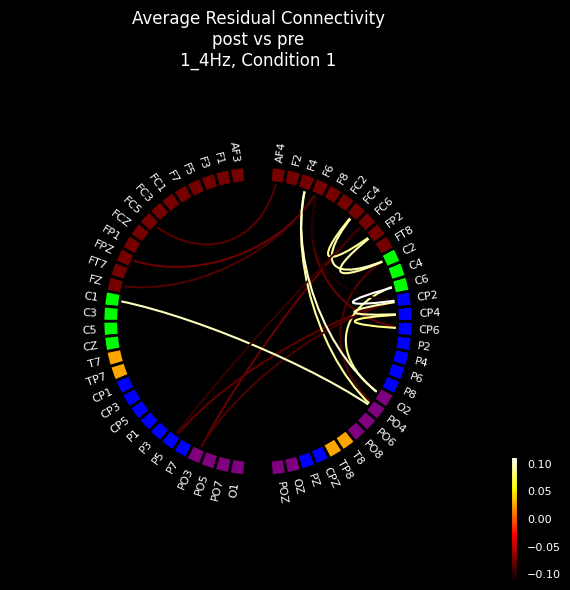

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/1_4/avg_residual_conn_1_4_cond1_pre_vs_post.png


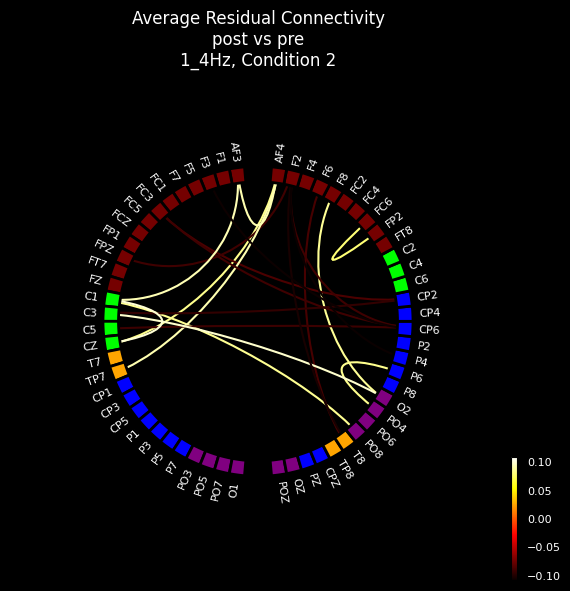

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/1_4/avg_residual_conn_1_4_cond2_pre_vs_post.png


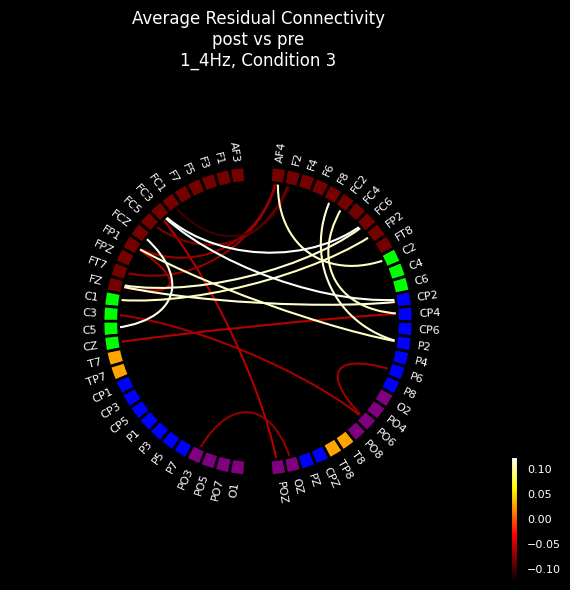

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/1_4/avg_residual_conn_1_4_cond3_pre_vs_post.png


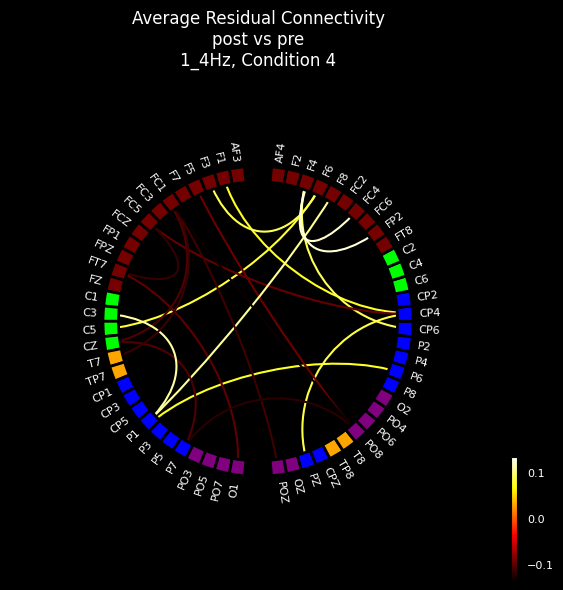

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/1_4/avg_residual_conn_1_4_cond4_pre_vs_post.png


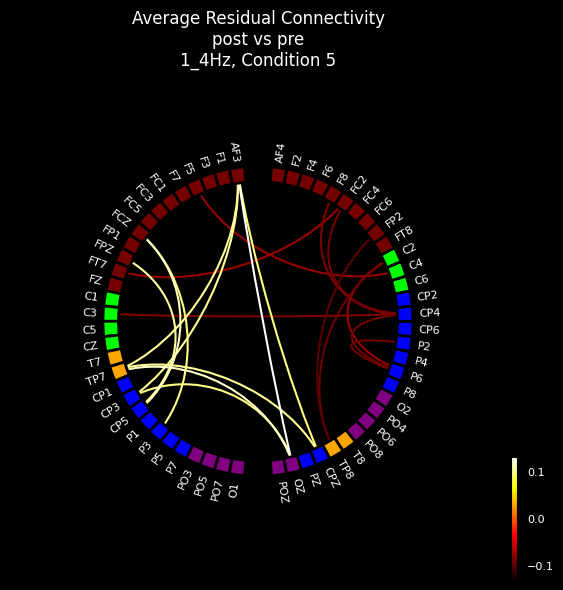

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/1_4/avg_residual_conn_1_4_cond5_pre_vs_post.png


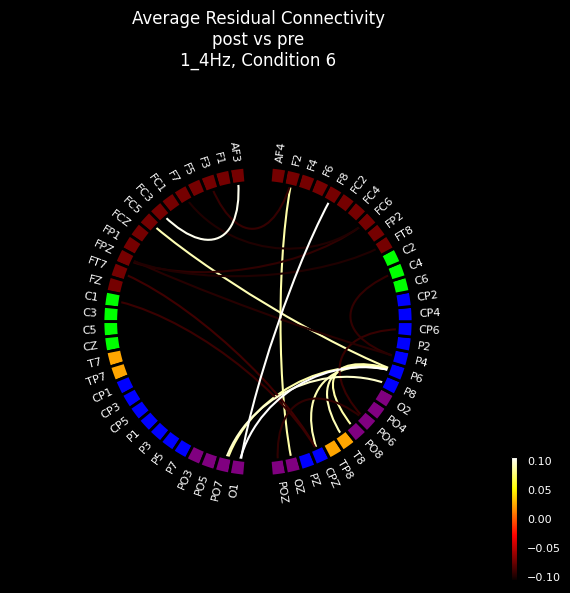

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/1_4/avg_residual_conn_1_4_cond6_pre_vs_post.png


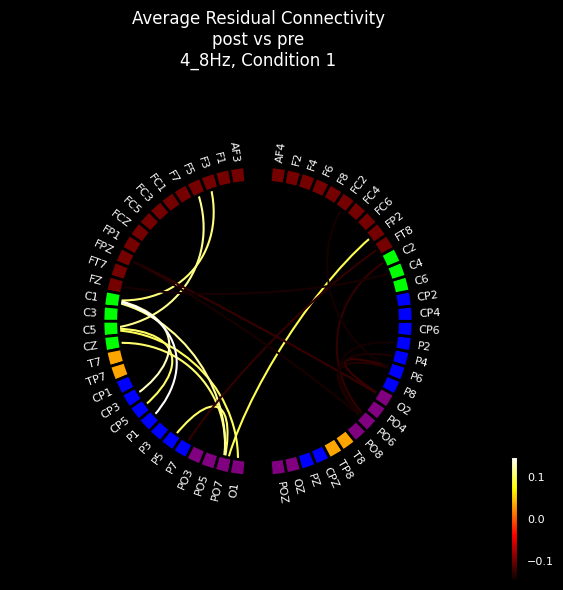

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/4_8/avg_residual_conn_4_8_cond1_pre_vs_post.png


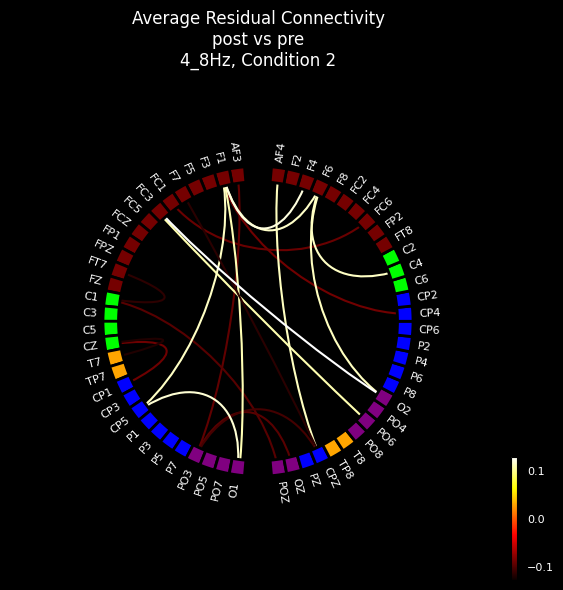

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/4_8/avg_residual_conn_4_8_cond2_pre_vs_post.png


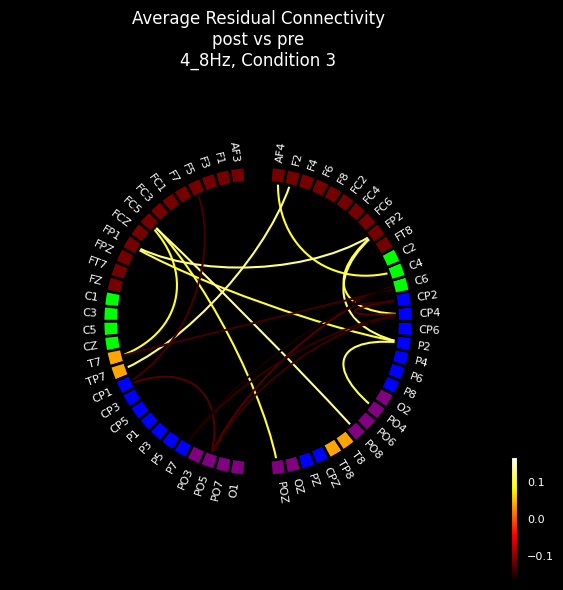

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/4_8/avg_residual_conn_4_8_cond3_pre_vs_post.png


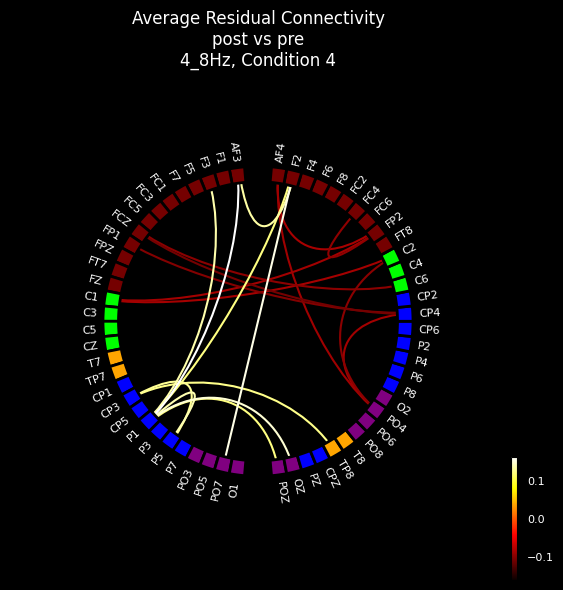

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/4_8/avg_residual_conn_4_8_cond4_pre_vs_post.png


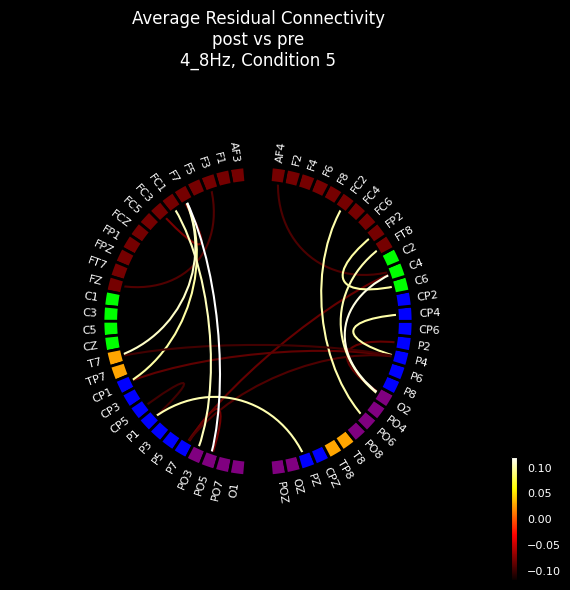

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/4_8/avg_residual_conn_4_8_cond5_pre_vs_post.png


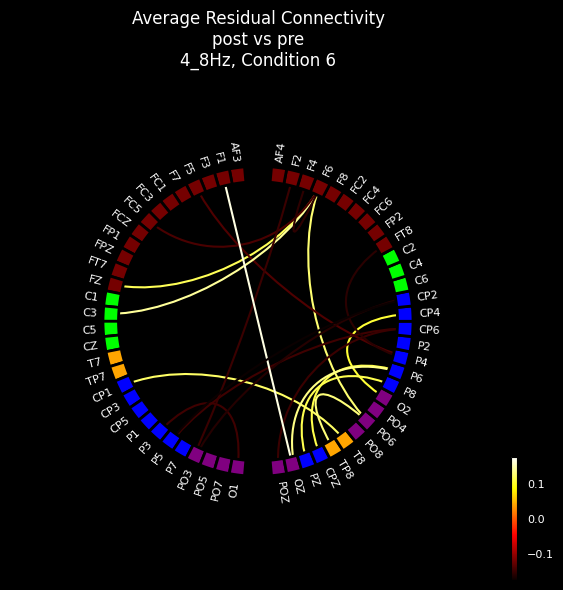

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/4_8/avg_residual_conn_4_8_cond6_pre_vs_post.png


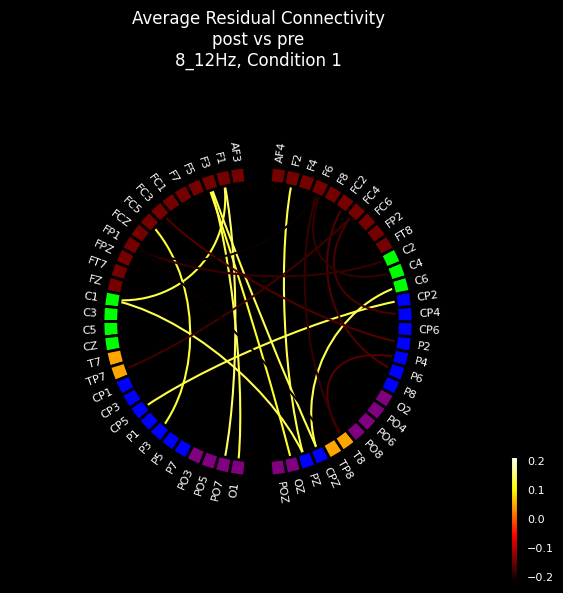

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/8_12/avg_residual_conn_8_12_cond1_pre_vs_post.png


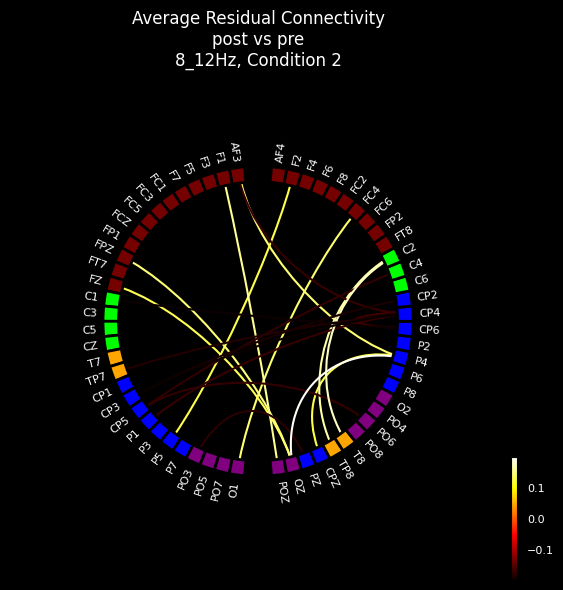

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/8_12/avg_residual_conn_8_12_cond2_pre_vs_post.png


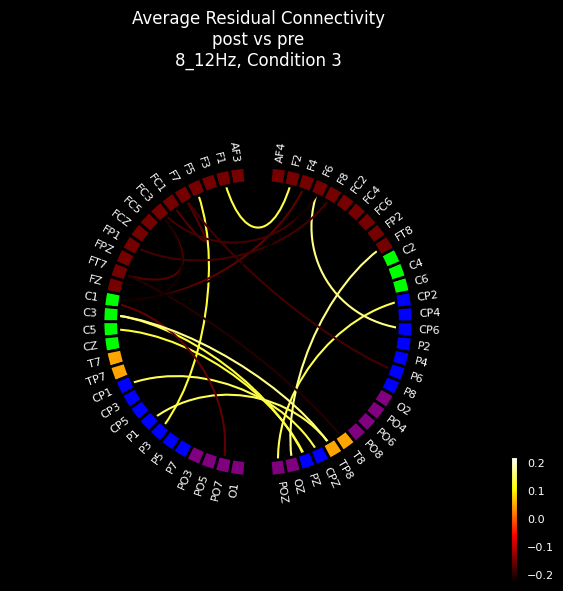

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/8_12/avg_residual_conn_8_12_cond3_pre_vs_post.png


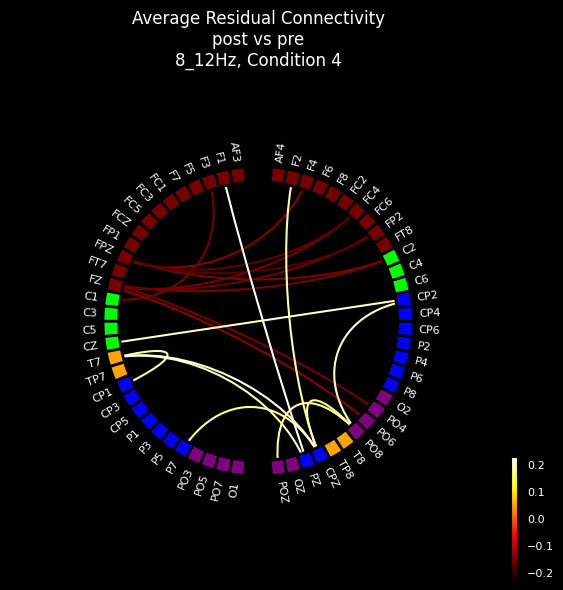

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/8_12/avg_residual_conn_8_12_cond4_pre_vs_post.png


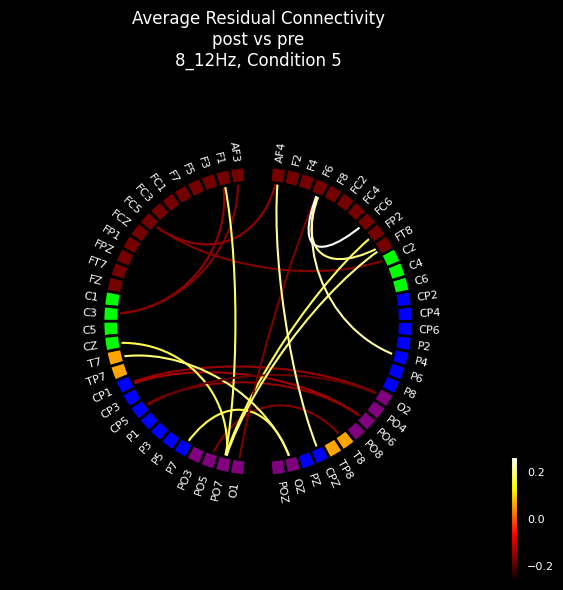

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/8_12/avg_residual_conn_8_12_cond5_pre_vs_post.png


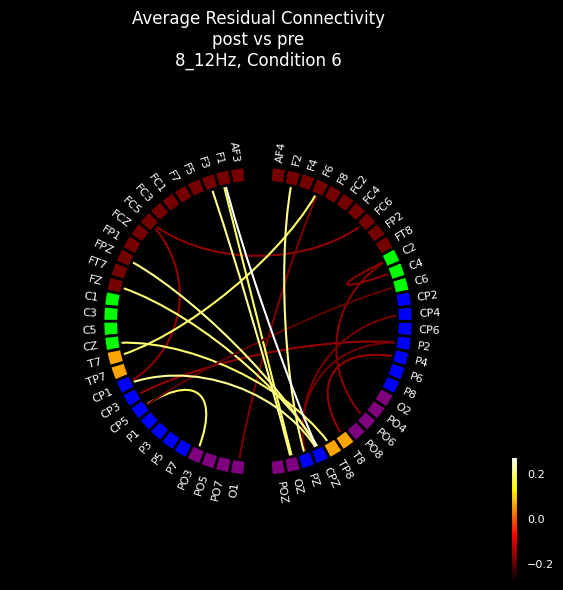

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/8_12/avg_residual_conn_8_12_cond6_pre_vs_post.png


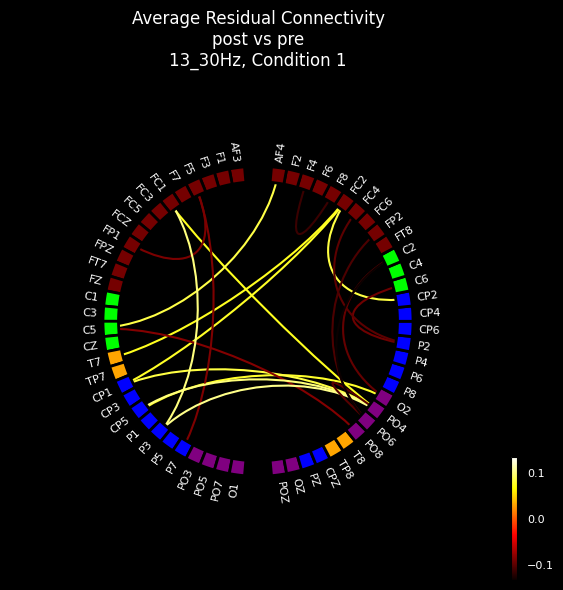

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/13_30/avg_residual_conn_13_30_cond1_pre_vs_post.png


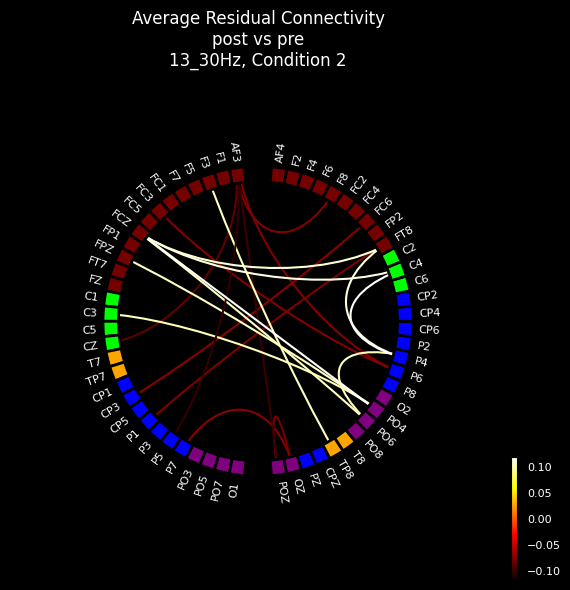

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/13_30/avg_residual_conn_13_30_cond2_pre_vs_post.png


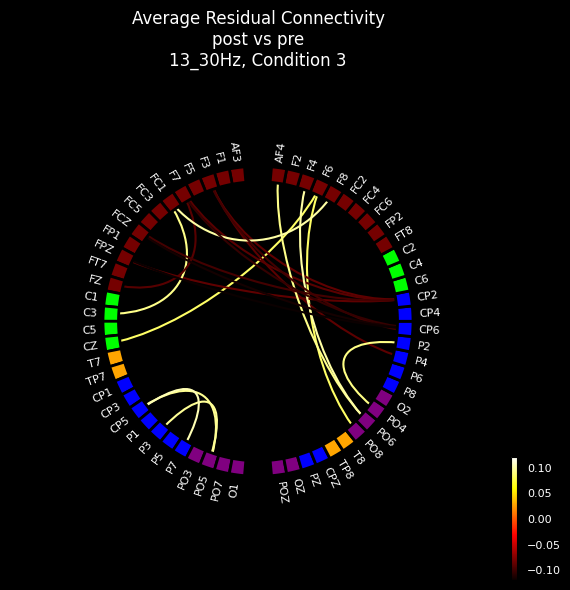

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/13_30/avg_residual_conn_13_30_cond3_pre_vs_post.png


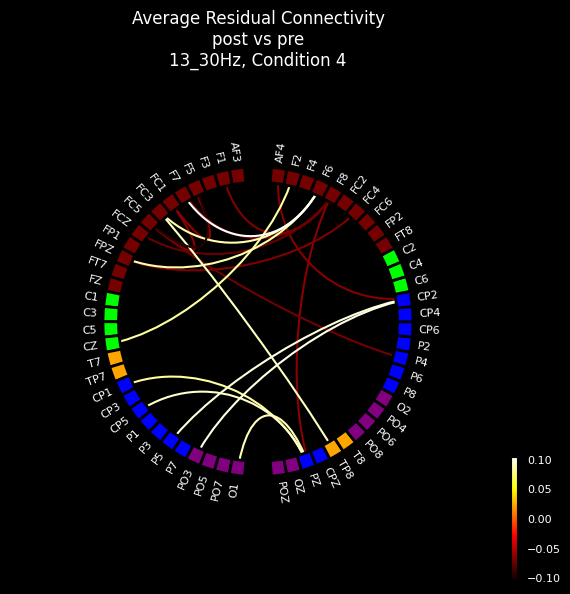

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/13_30/avg_residual_conn_13_30_cond4_pre_vs_post.png


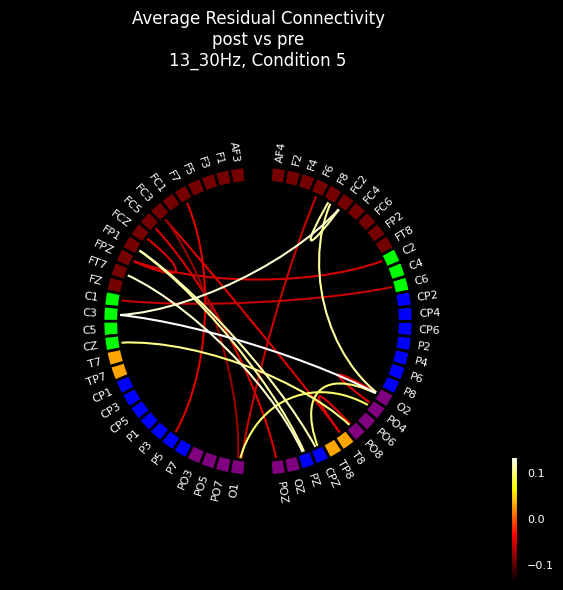

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/13_30/avg_residual_conn_13_30_cond5_pre_vs_post.png


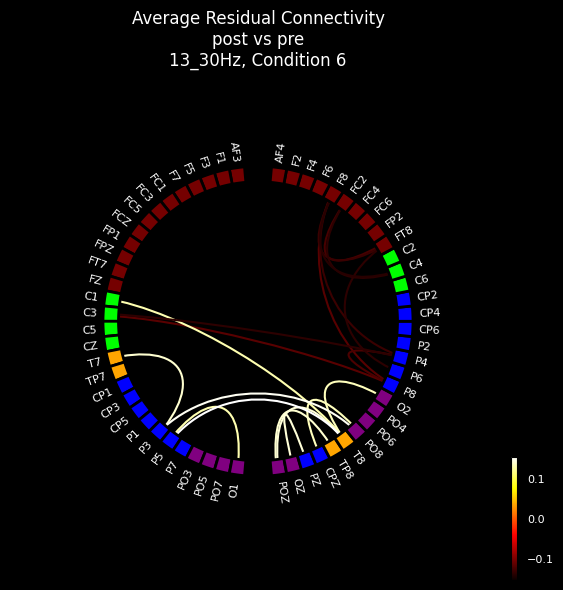

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/13_30/avg_residual_conn_13_30_cond6_pre_vs_post.png


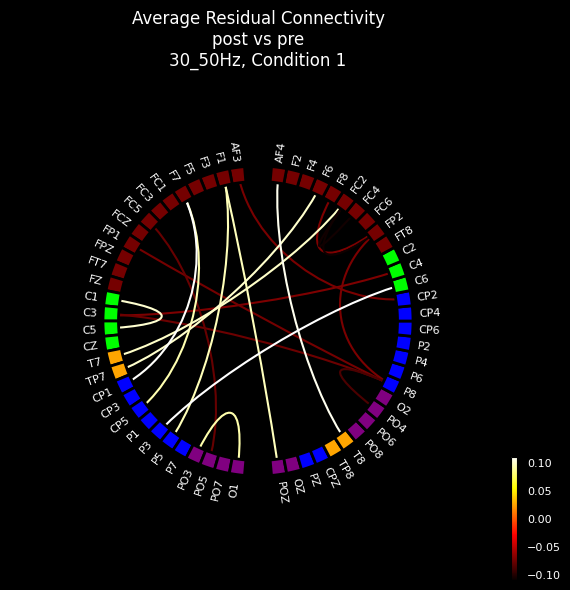

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/30_50/avg_residual_conn_30_50_cond1_pre_vs_post.png


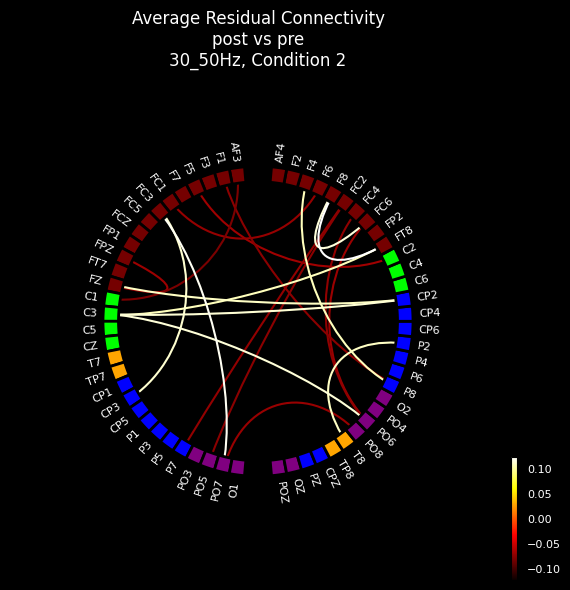

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/30_50/avg_residual_conn_30_50_cond2_pre_vs_post.png


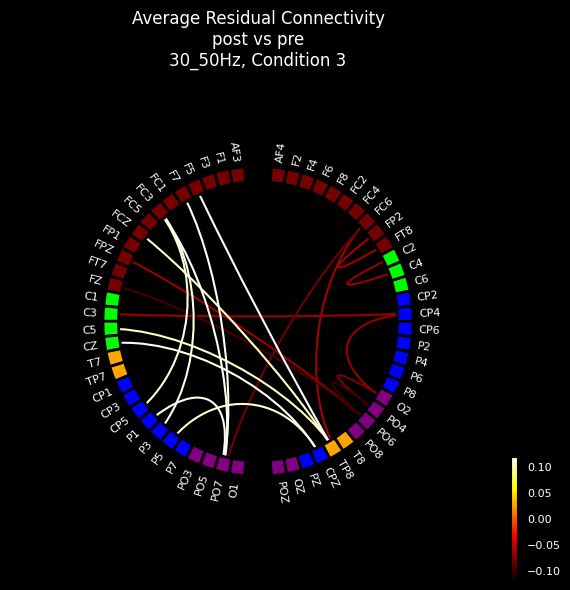

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/30_50/avg_residual_conn_30_50_cond3_pre_vs_post.png


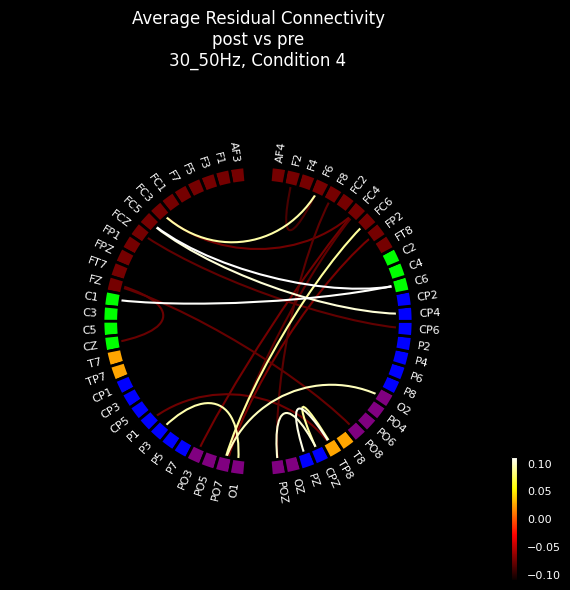

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/30_50/avg_residual_conn_30_50_cond4_pre_vs_post.png


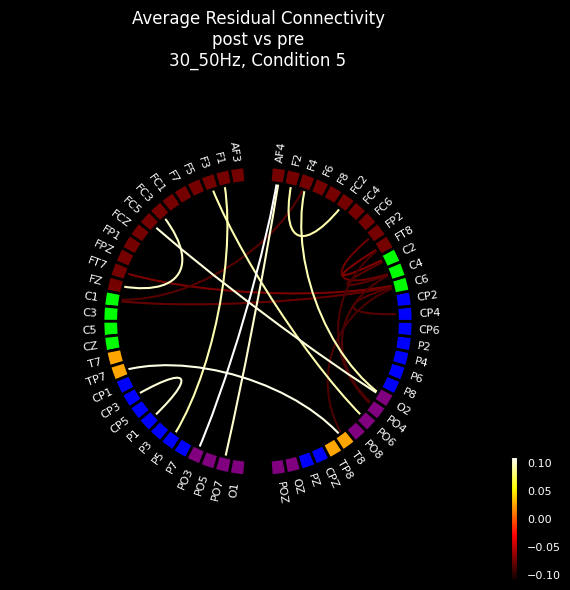

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/30_50/avg_residual_conn_30_50_cond5_pre_vs_post.png


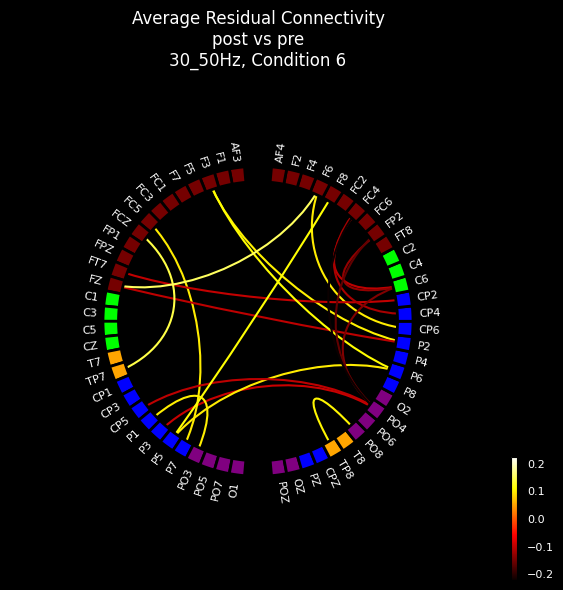

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/30_50/avg_residual_conn_30_50_cond6_pre_vs_post.png


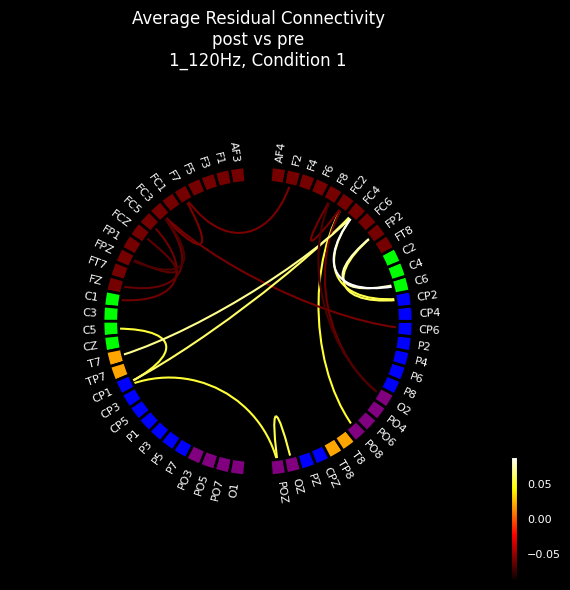

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/1_120/avg_residual_conn_1_120_cond1_pre_vs_post.png


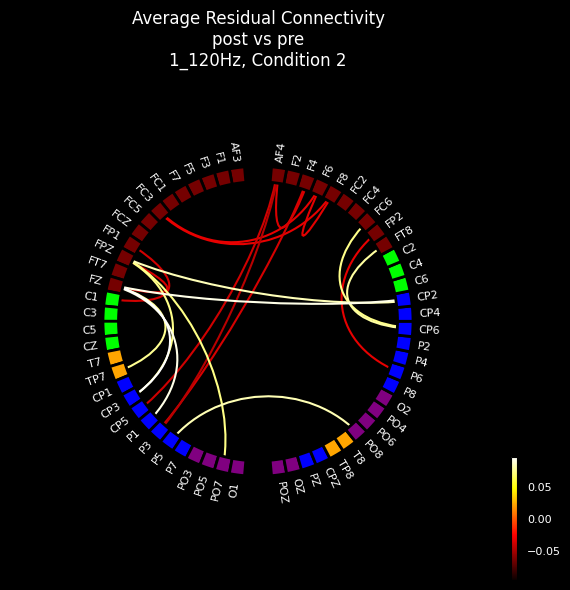

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/1_120/avg_residual_conn_1_120_cond2_pre_vs_post.png


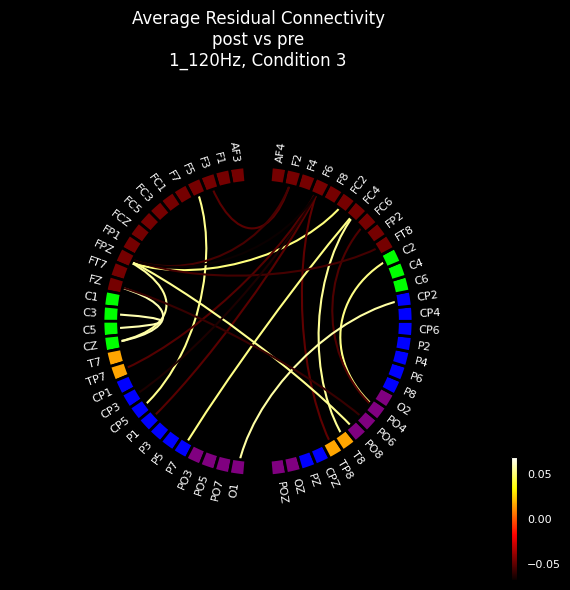

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/1_120/avg_residual_conn_1_120_cond3_pre_vs_post.png


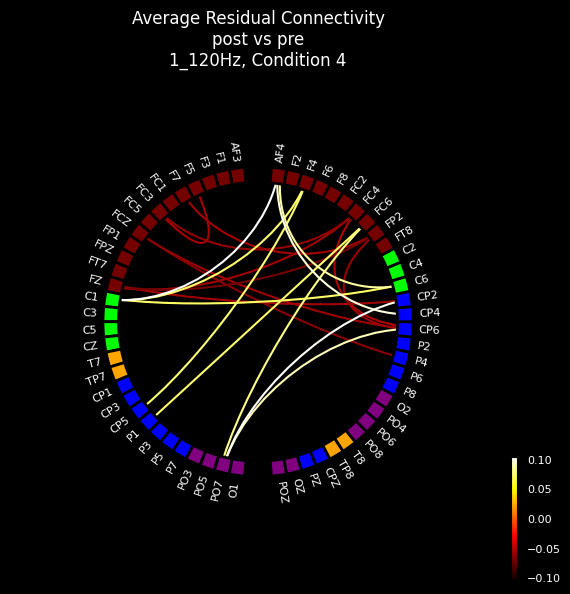

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/1_120/avg_residual_conn_1_120_cond4_pre_vs_post.png


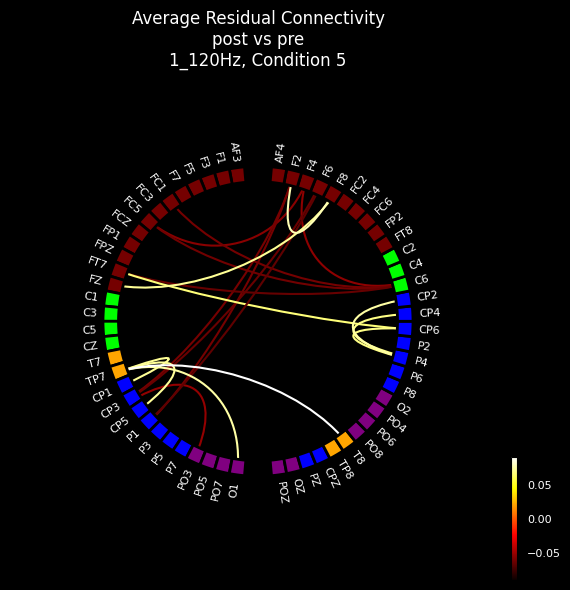

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/1_120/avg_residual_conn_1_120_cond5_pre_vs_post.png


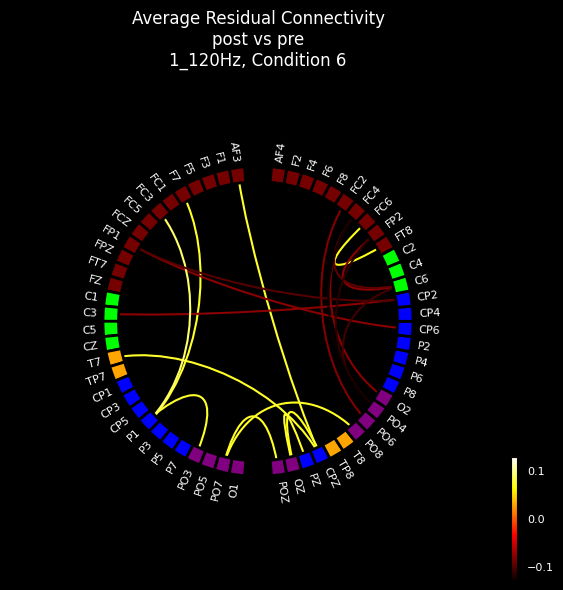

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_post/1_120/avg_residual_conn_1_120_cond6_pre_vs_post.png


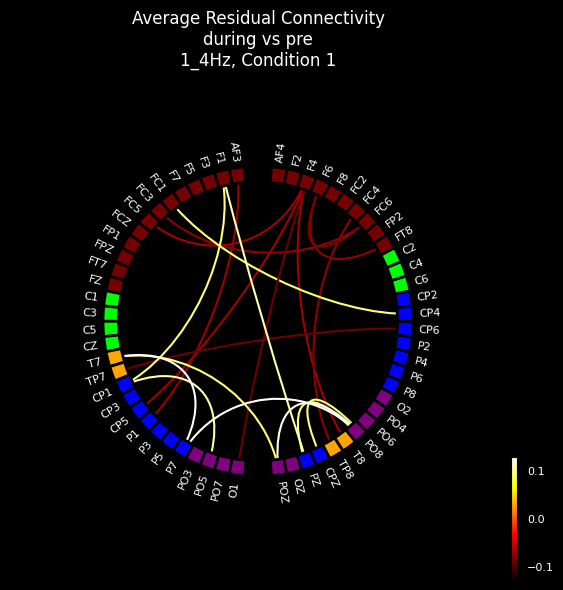

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/1_4/avg_residual_conn_1_4_cond1_pre_vs_during.png


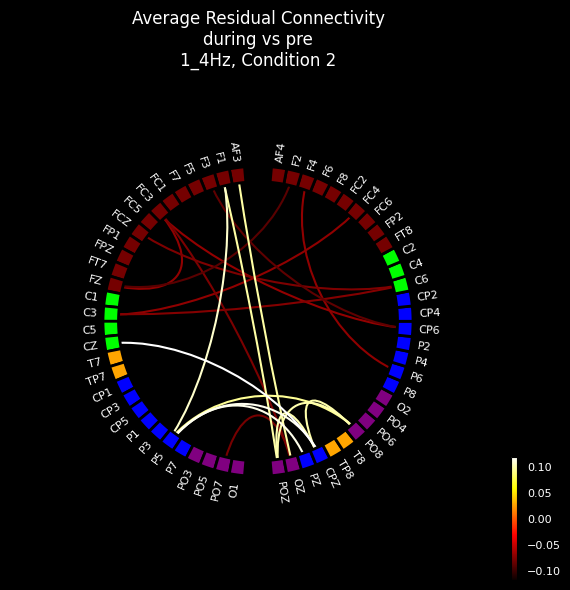

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/1_4/avg_residual_conn_1_4_cond2_pre_vs_during.png


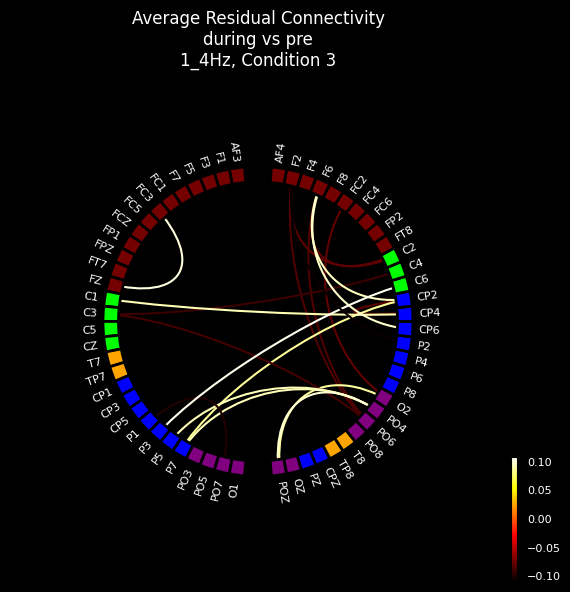

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/1_4/avg_residual_conn_1_4_cond3_pre_vs_during.png


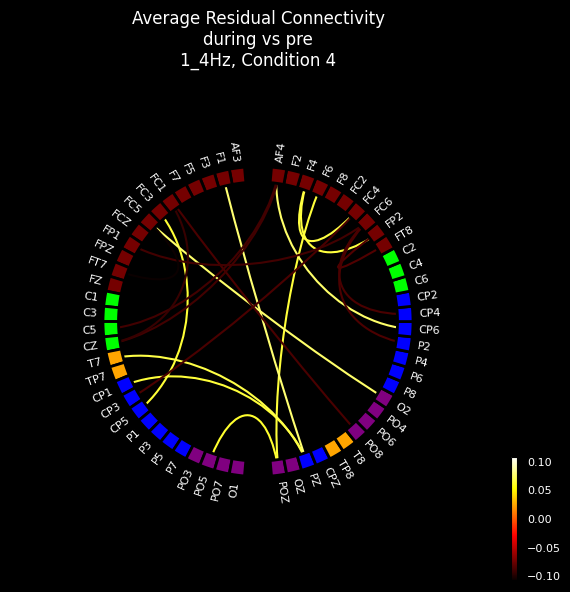

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/1_4/avg_residual_conn_1_4_cond4_pre_vs_during.png


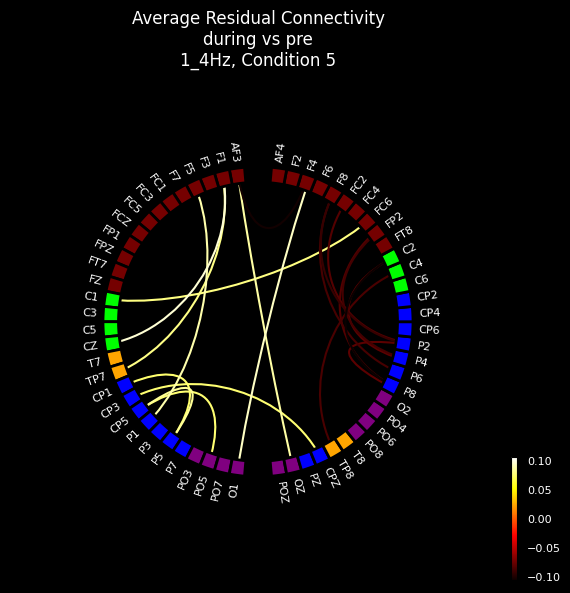

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/1_4/avg_residual_conn_1_4_cond5_pre_vs_during.png


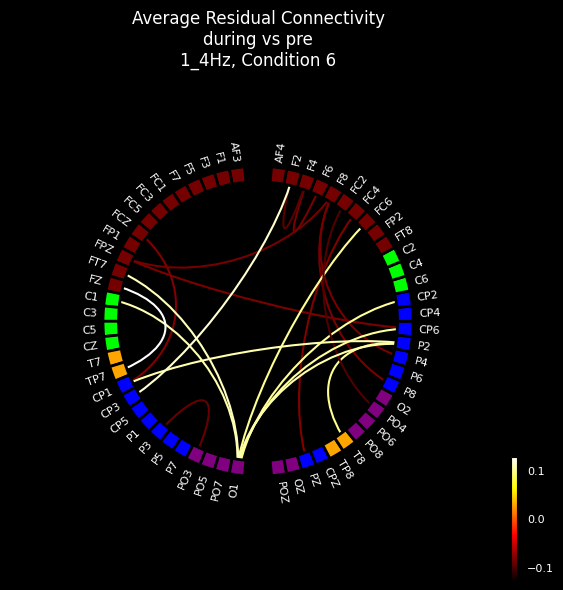

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/1_4/avg_residual_conn_1_4_cond6_pre_vs_during.png


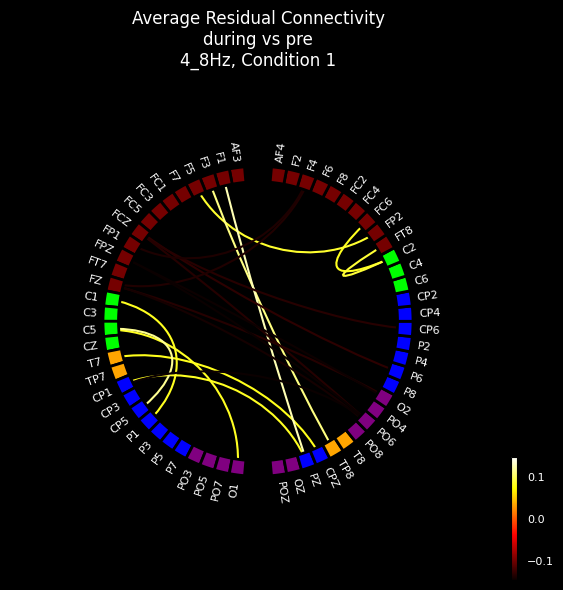

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/4_8/avg_residual_conn_4_8_cond1_pre_vs_during.png


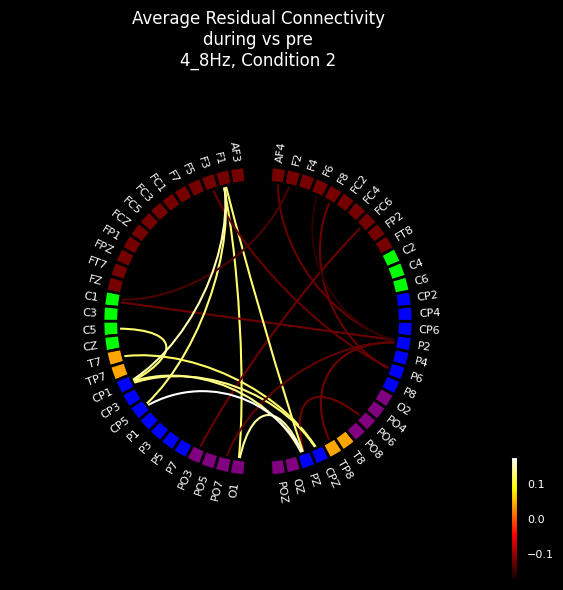

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/4_8/avg_residual_conn_4_8_cond2_pre_vs_during.png


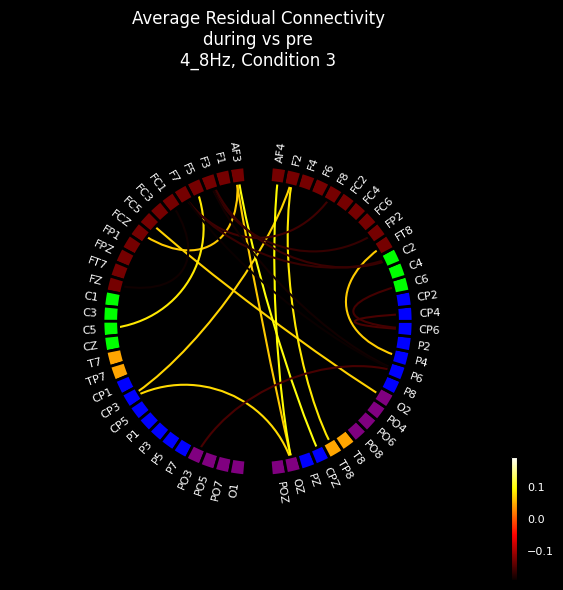

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/4_8/avg_residual_conn_4_8_cond3_pre_vs_during.png


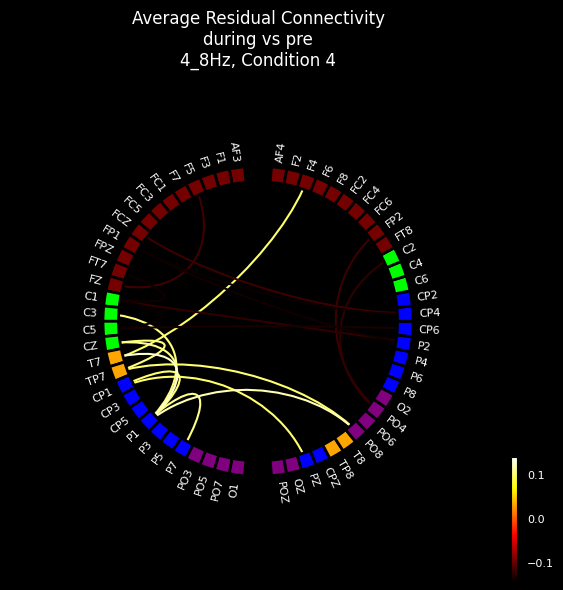

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/4_8/avg_residual_conn_4_8_cond4_pre_vs_during.png


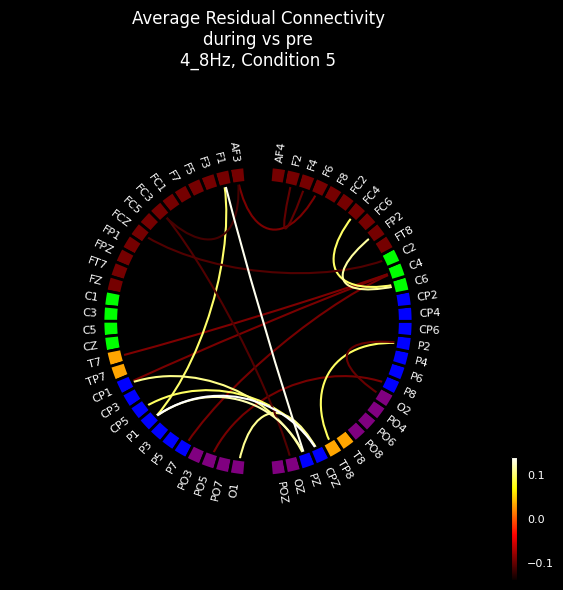

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/4_8/avg_residual_conn_4_8_cond5_pre_vs_during.png


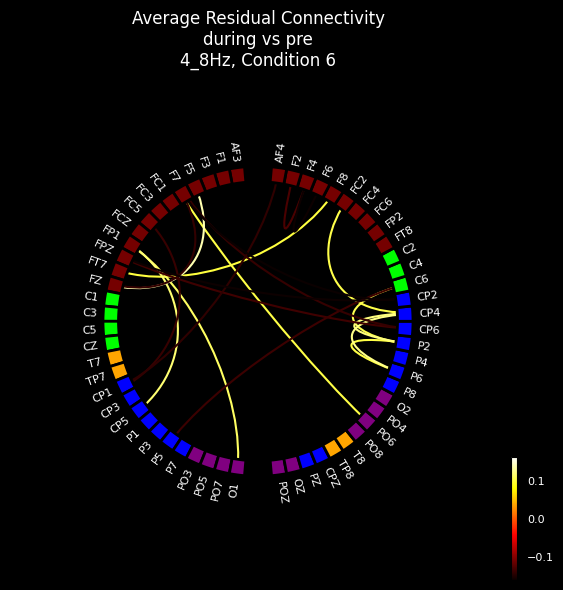

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/4_8/avg_residual_conn_4_8_cond6_pre_vs_during.png


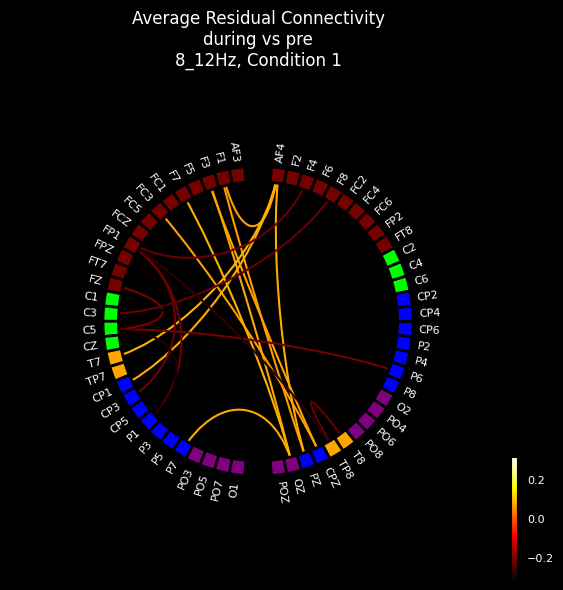

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/8_12/avg_residual_conn_8_12_cond1_pre_vs_during.png


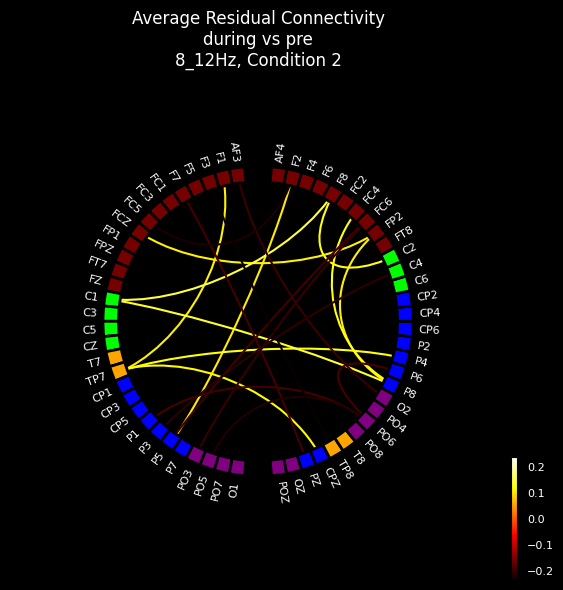

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/8_12/avg_residual_conn_8_12_cond2_pre_vs_during.png


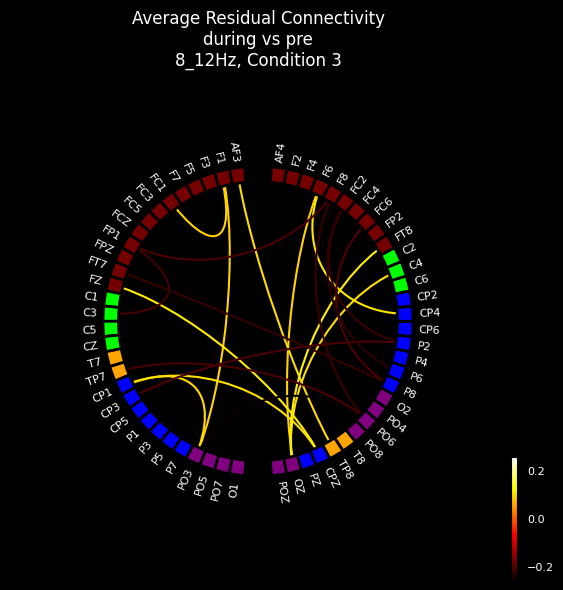

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/8_12/avg_residual_conn_8_12_cond3_pre_vs_during.png


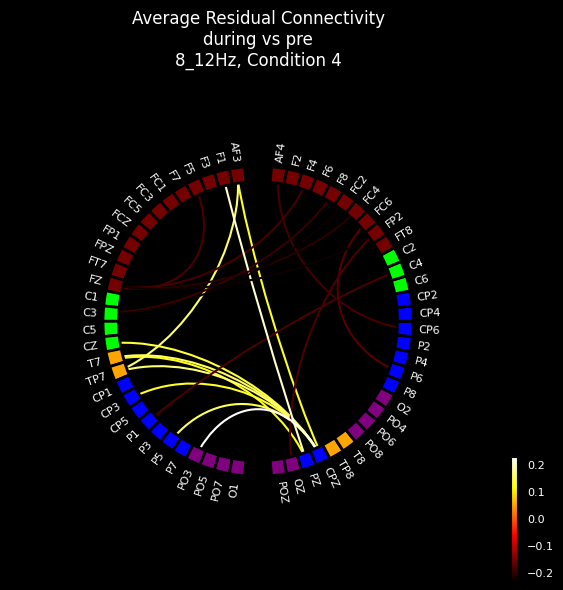

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/8_12/avg_residual_conn_8_12_cond4_pre_vs_during.png


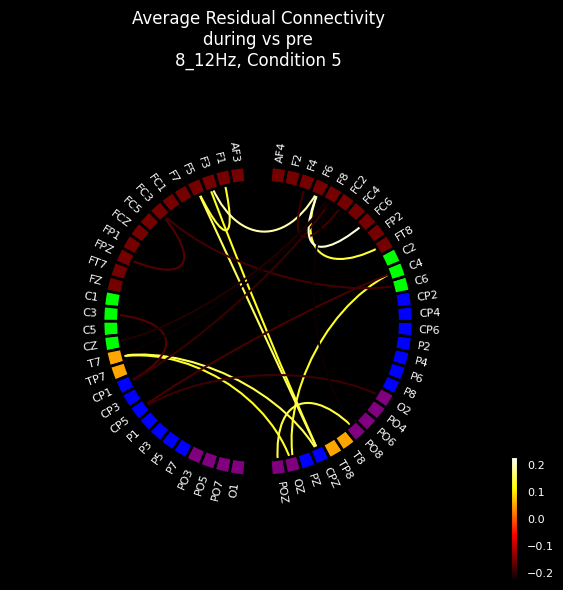

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/8_12/avg_residual_conn_8_12_cond5_pre_vs_during.png


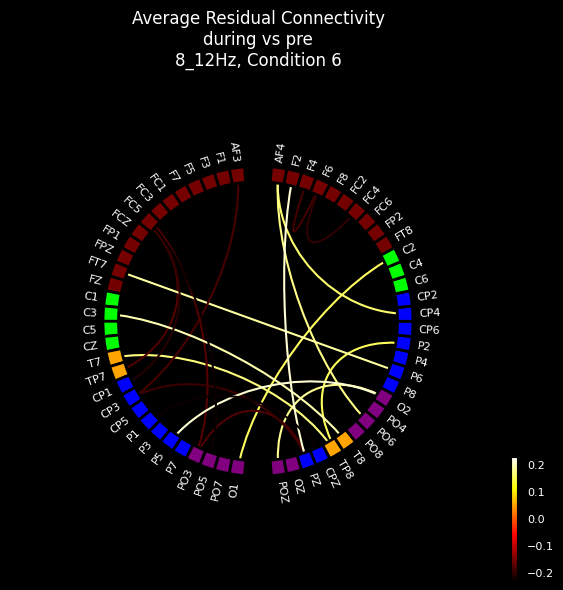

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/8_12/avg_residual_conn_8_12_cond6_pre_vs_during.png


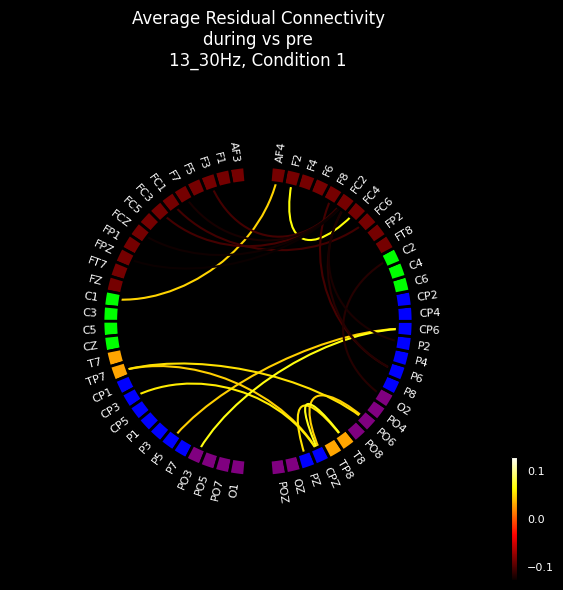

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/13_30/avg_residual_conn_13_30_cond1_pre_vs_during.png


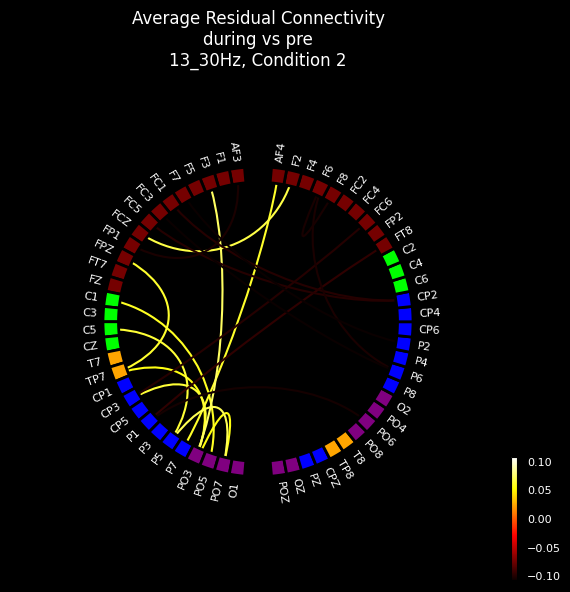

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/13_30/avg_residual_conn_13_30_cond2_pre_vs_during.png


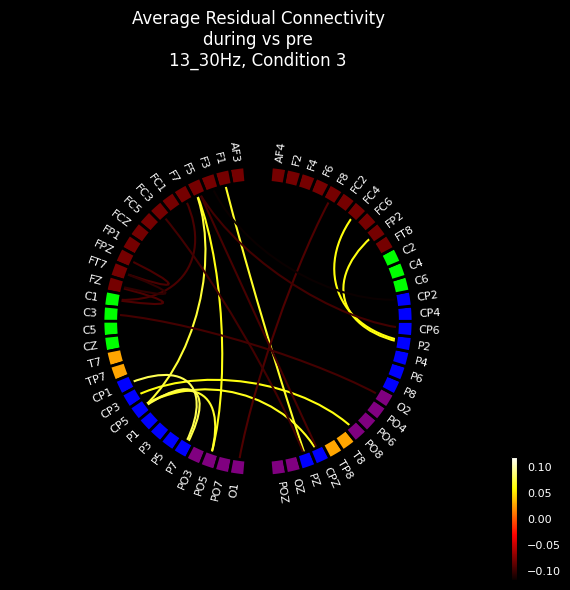

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/13_30/avg_residual_conn_13_30_cond3_pre_vs_during.png


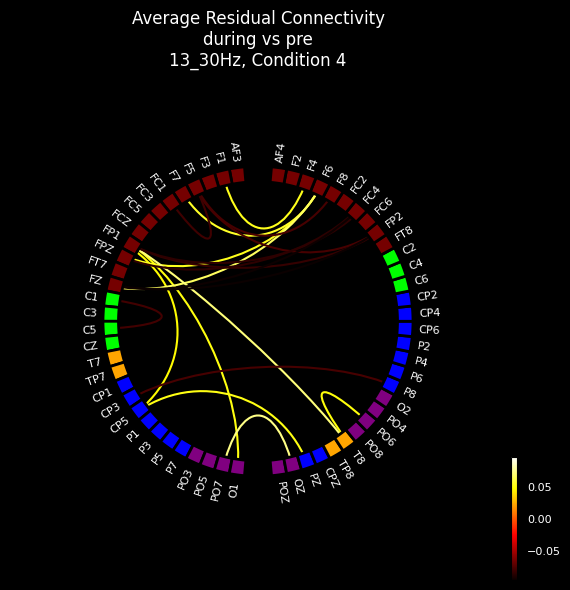

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/13_30/avg_residual_conn_13_30_cond4_pre_vs_during.png


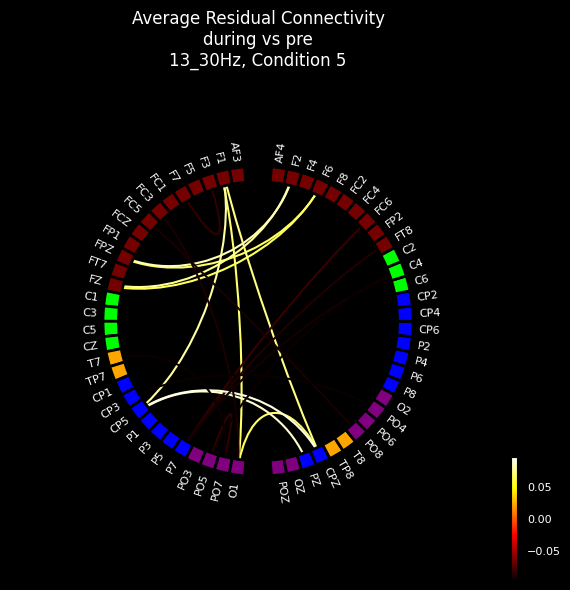

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/13_30/avg_residual_conn_13_30_cond5_pre_vs_during.png


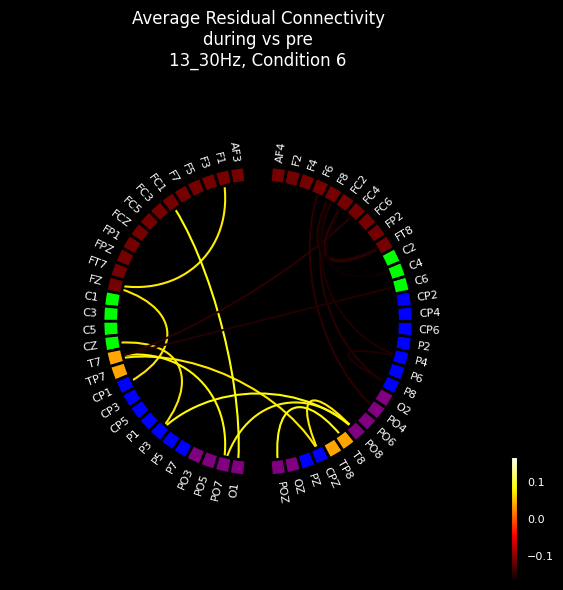

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/13_30/avg_residual_conn_13_30_cond6_pre_vs_during.png


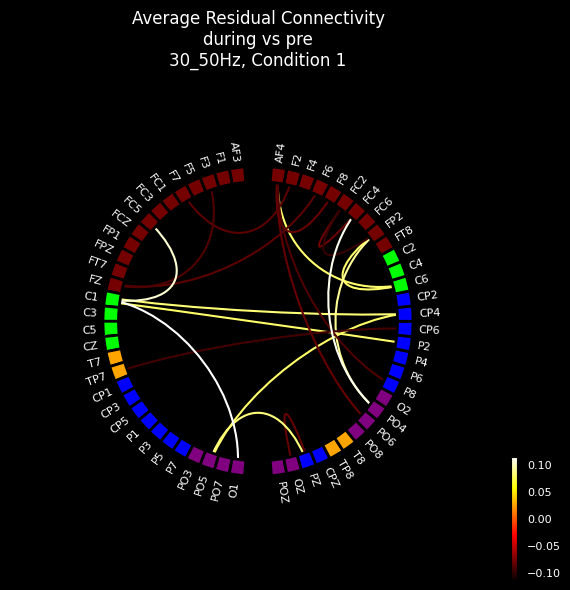

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/30_50/avg_residual_conn_30_50_cond1_pre_vs_during.png


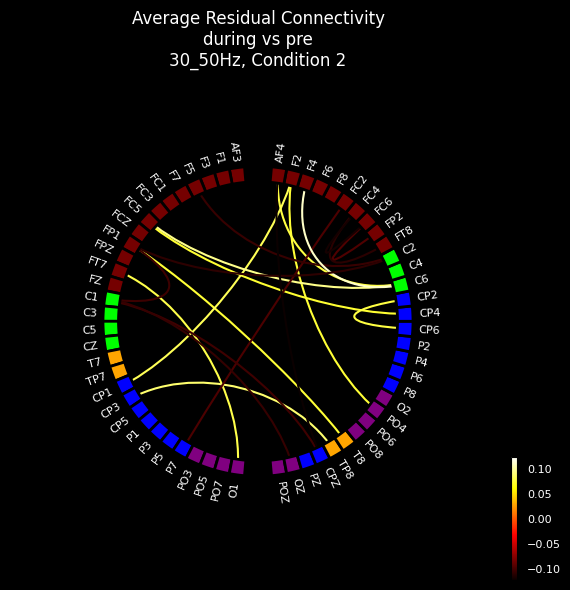

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/30_50/avg_residual_conn_30_50_cond2_pre_vs_during.png


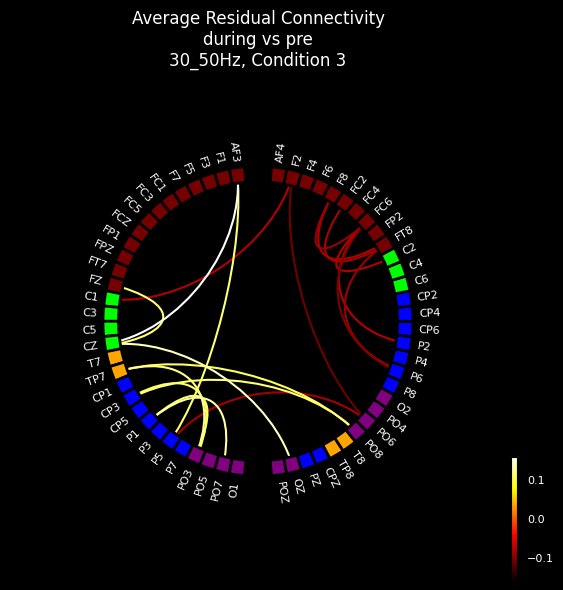

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/30_50/avg_residual_conn_30_50_cond3_pre_vs_during.png


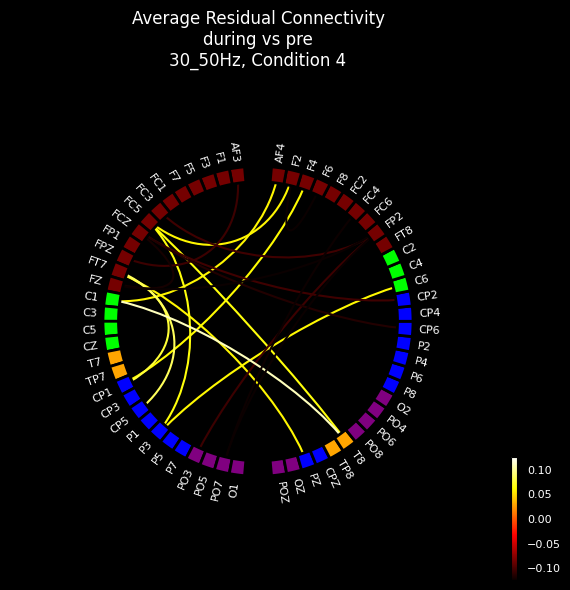

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/30_50/avg_residual_conn_30_50_cond4_pre_vs_during.png


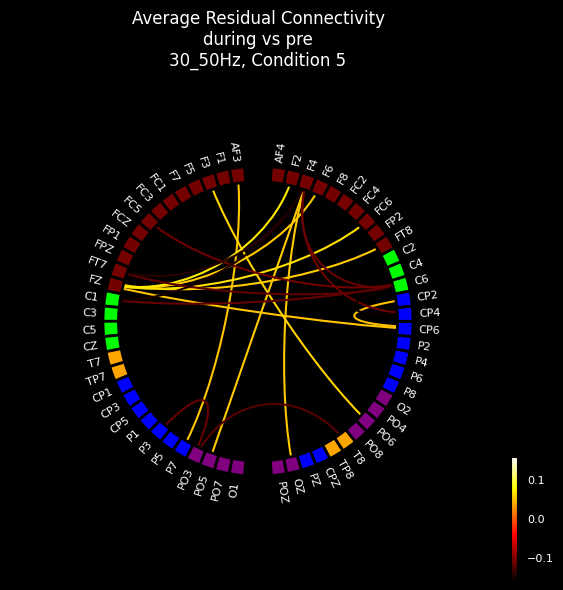

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/30_50/avg_residual_conn_30_50_cond5_pre_vs_during.png


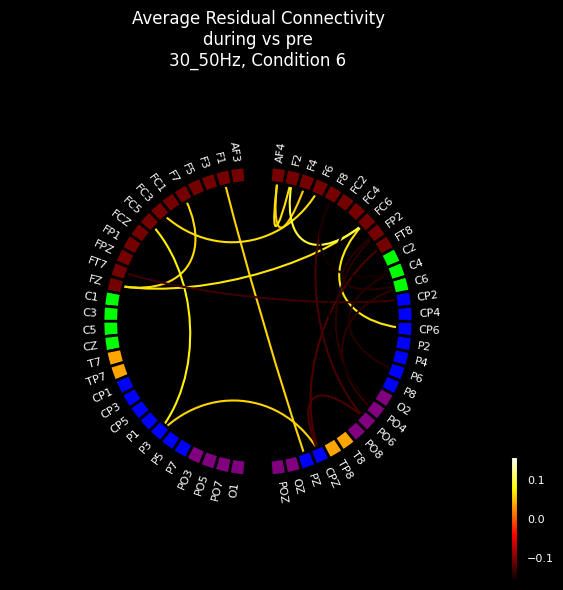

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/30_50/avg_residual_conn_30_50_cond6_pre_vs_during.png


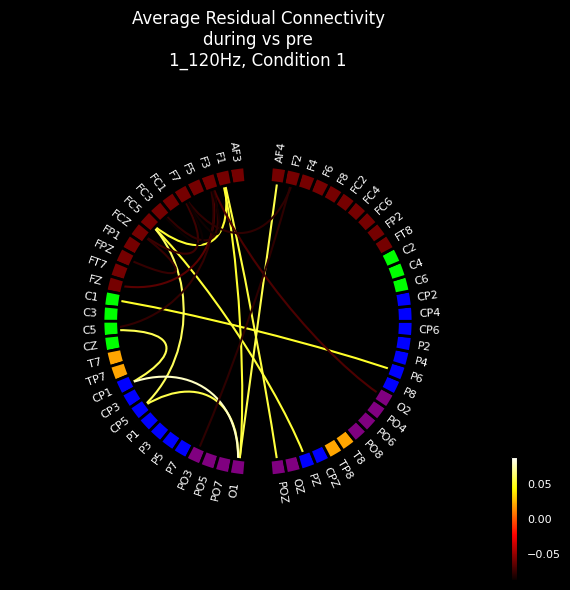

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/1_120/avg_residual_conn_1_120_cond1_pre_vs_during.png


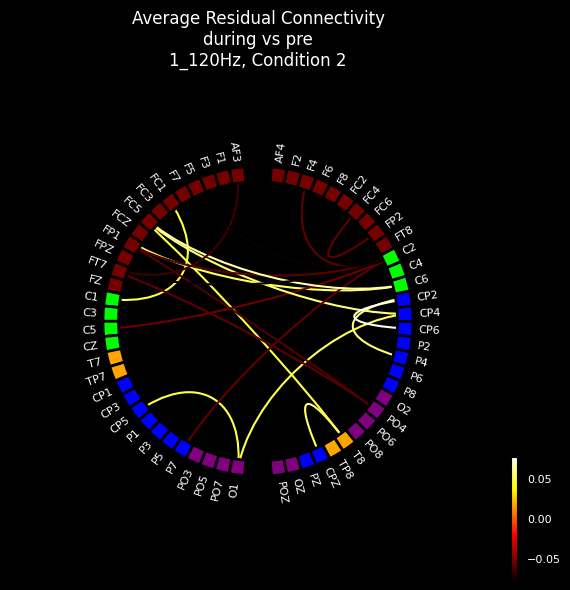

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/1_120/avg_residual_conn_1_120_cond2_pre_vs_during.png


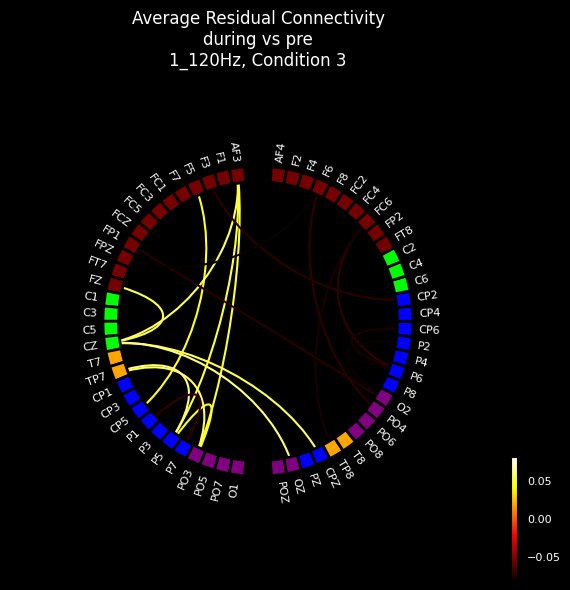

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/1_120/avg_residual_conn_1_120_cond3_pre_vs_during.png


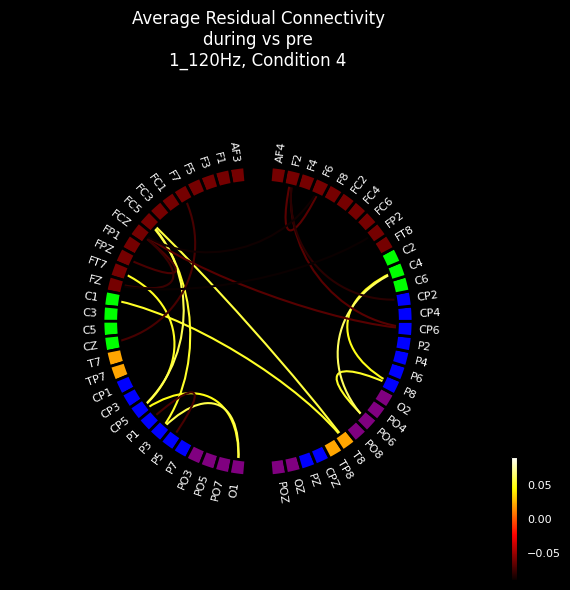

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/1_120/avg_residual_conn_1_120_cond4_pre_vs_during.png


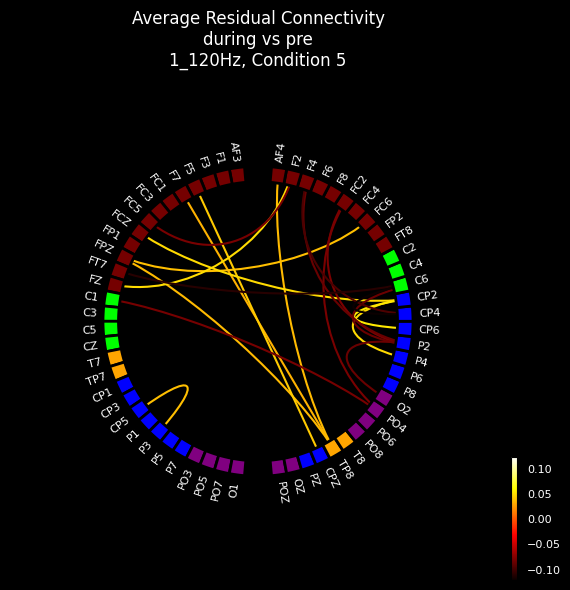

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/1_120/avg_residual_conn_1_120_cond5_pre_vs_during.png


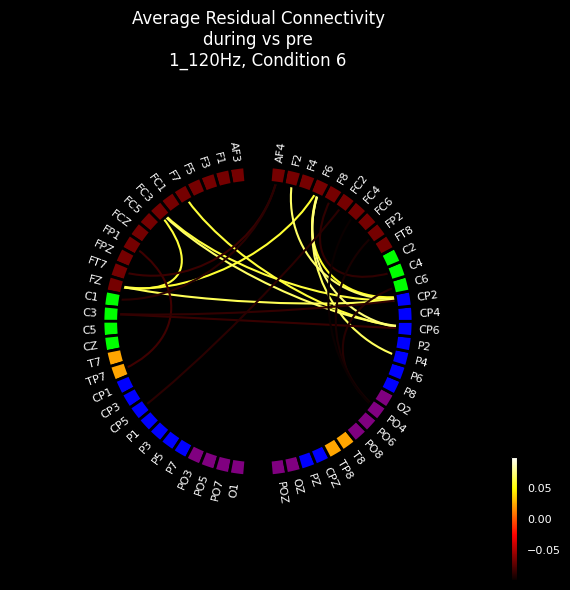

Figure saved as ./csd_results/residual_filter_banks_results/pre_vs_during/1_120/avg_residual_conn_1_120_cond6_pre_vs_during.png


In [22]:
def plot_average_residual_connectivity(
    hierarchy,
    conditions=[1, 2, 3, 4, 5, 6],
    freq_bands=["1_4", "4_8", "8_12", "13_30", "30_50", "1_120"],
    state1="pre",
    state2="post",
    n_lines=20,
    figsize=(8, 8),
    base_path="./figures",
    is_save=False,
):
    """
    Plot average residual connectivity across all patients for each frequency band and condition.

    Args:
        hierarchy (dict): The hierarchical data structure
        conditions (list): List of conditions to analyze
        freq_bands (list): List of frequency bands to analyze
        state1 (str): First state ('pre', 'during', 'post'). Default is 'pre'
        state2 (str): Second state ('pre', 'during', 'post'). Default is 'post'
        n_lines (int): Number of strongest connections to show
        figsize (tuple): Figure size for each plot
        base_path (str): Base path for saving figures
        is_save (bool): Whether to save the figures

    Returns:
        dict: Dictionary containing the average residual matrices for each condition and frequency band
    """
    # Dictionary to store average residuals
    avg_residuals = {}

    # Get channel information
    channel_names = get_channel_5_colors()
    node_angles, node_order, node_colors = get_circular_plot_requirements(channel_names)

    # Process each frequency band
    for freq_band in freq_bands:
        avg_residuals[freq_band] = {}

        # Process each condition
        for condition in conditions:
            # List to store residuals for all patients
            all_residuals = []

            # Process each patient
            for patient in range(2, 22):  # Patients 2-21
                try:
                    # Get data for both states
                    conn1 = hierarchy[freq_band][condition][patient][state1]
                    conn2 = hierarchy[freq_band][condition][patient][state2]

                    if conn1 is not None and conn2 is not None:
                        # Convert to dense arrays and get first frequency
                        conn1_data = conn1.get_data(output="dense")[:, :, 0]
                        conn2_data = conn2.get_data(output="dense")[:, :, 0]

                        # Calculate residual (state2 - state1)
                        residual = conn2_data - conn1_data
                        all_residuals.append(residual)

                except (KeyError, AttributeError) as e:
                    print(
                        f"Skipping patient {patient} for freq_band {freq_band}, condition {condition}: {e}"
                    )

            if all_residuals:
                # Calculate average residual across patients
                avg_residual = np.mean(all_residuals, axis=0)
                avg_residuals[freq_band][condition] = avg_residual

                # Create a mask for top positive and negative connections
                n_lines_each = n_lines // 2
                pos_flat_idx = np.argsort(avg_residual.flatten())[-n_lines_each:]
                neg_flat_idx = np.argsort(avg_residual.flatten())[:n_lines_each]

                # Create masked residual matrix
                mask = np.zeros_like(avg_residual, dtype=bool)
                mask.flat[pos_flat_idx] = True
                mask.flat[neg_flat_idx] = True
                masked_residual = np.zeros_like(avg_residual)
                masked_residual[mask] = avg_residual[mask]

                # Create figure
                fig, ax = plt.subplots(
                    figsize=figsize, facecolor="black", subplot_kw=dict(polar=True)
                )

                # Plot connectivity circle
                plot_connectivity_circle(
                    con=masked_residual,
                    node_names=channel_names,
                    n_lines=n_lines,
                    node_angles=node_angles,
                    node_colors=node_colors,
                    title=f"Average Residual Connectivity\n{state2} vs {state1}\n{freq_band}Hz, Condition {condition}",
                    ax=ax,
                    vmin=-np.max(abs(masked_residual)),
                    vmax=np.max(abs(masked_residual)),
                )

                # Adjust layout
                fig.tight_layout()

                # Save figure if requested
                if is_save:
                    save_dir = f"{base_path}/{freq_band}"
                    os.makedirs(save_dir, exist_ok=True)
                    filename = f"{save_dir}/avg_residual_conn_{freq_band}_cond{condition}_{state1}_vs_{state2}.png"
                    fig.savefig(filename, dpi=300)
                    print(f"Figure saved as {filename}")

                plt.close(fig)

    return avg_residuals


# Example usage:
avg_residuals = plot_average_residual_connectivity(
    hierarchy=hierarchy,
    conditions=[1, 2, 3, 4, 5, 6],
    freq_bands=["1_4", "4_8", "8_12", "13_30", "30_50", "1_120"],
    state1="pre",
    state2="post",
    n_lines=20,
    base_path="./csd_results/residual_filter_banks_results/pre_vs_post",
    is_save=True,
)

avg_residuals = plot_average_residual_connectivity(
    hierarchy=hierarchy,
    conditions=[1, 2, 3, 4, 5, 6],
    freq_bands=["1_4", "4_8", "8_12", "13_30", "30_50", "1_120"],
    state1="pre",
    state2="during",
    n_lines=20,
    base_path="./csd_results/residual_filter_banks_results/pre_vs_during",
    is_save=True,
)
